In [1]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
import warnings
warnings.filterwarnings('ignore')

# CNN con MSINT Fashion dataset

## Importe de librerias y set de datos

Importe de librerias junto a set de datos.

Luego trabajo sobre estas

In [3]:
# Librerias y set de datos

import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

from keras.datasets import fashion_mnist
(images_train, labels_train), (images_test,labels_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Retoques al set de datos previos

labels_train=np.array(labels_train).reshape(-1,1)
labels_test=np.array(labels_test).reshape(-1,1)
labels_test.shape

(10000, 1)

In [5]:
# Datos cualitativos a cuantitativos

onehot=OneHotEncoder()

onehot.fit(labels_train)

labels_train=onehot.transform(labels_train)
labels_test=onehot.transform(labels_test)
labels_train=labels_train.toarray()
labels_test=labels_test.toarray()

In [7]:
# Normalización y tipo
images_train=np.array(images_train).reshape(60000,784)/255
images_test=np.array(images_test).reshape(10000,784)/255

images_train=images_train.reshape(60000,  28, 28,1).astype('float32')
images_test=images_test.reshape(10000, 28, 28,1).astype('float32')

## Red neuronal

### Creo la arquitectura

In [12]:
# Importo capas

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

In [10]:
image=Input(shape=(28,28,1))

conv1=Conv2D(32, (5, 5), activation='relu',padding='same')(image)
pool1=MaxPooling2D(pool_size=(2, 2))(conv1)

conv2=Conv2D(64, (5, 5),activation='relu',padding='same')(pool1)
pool2=MaxPooling2D(pool_size=(2, 2))(conv2)

flat_layer=Flatten()(pool2)

dense1=Dense(1024, activation='relu')(flat_layer)
drop1=Dropout(0.2)(dense1)

dense2=Dense(200, activation='relu')(drop1)
drop2=Dropout(0.2)(dense2)

output=Dense(10, activation='softmax')(drop2)

model=Model(inputs=image,outputs=output)

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       205,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,471,394 (13.24 MB)

 Trainable params: 3,471,394 (13.24 MB)

 Non-trainable params: 0 (0.00 B)

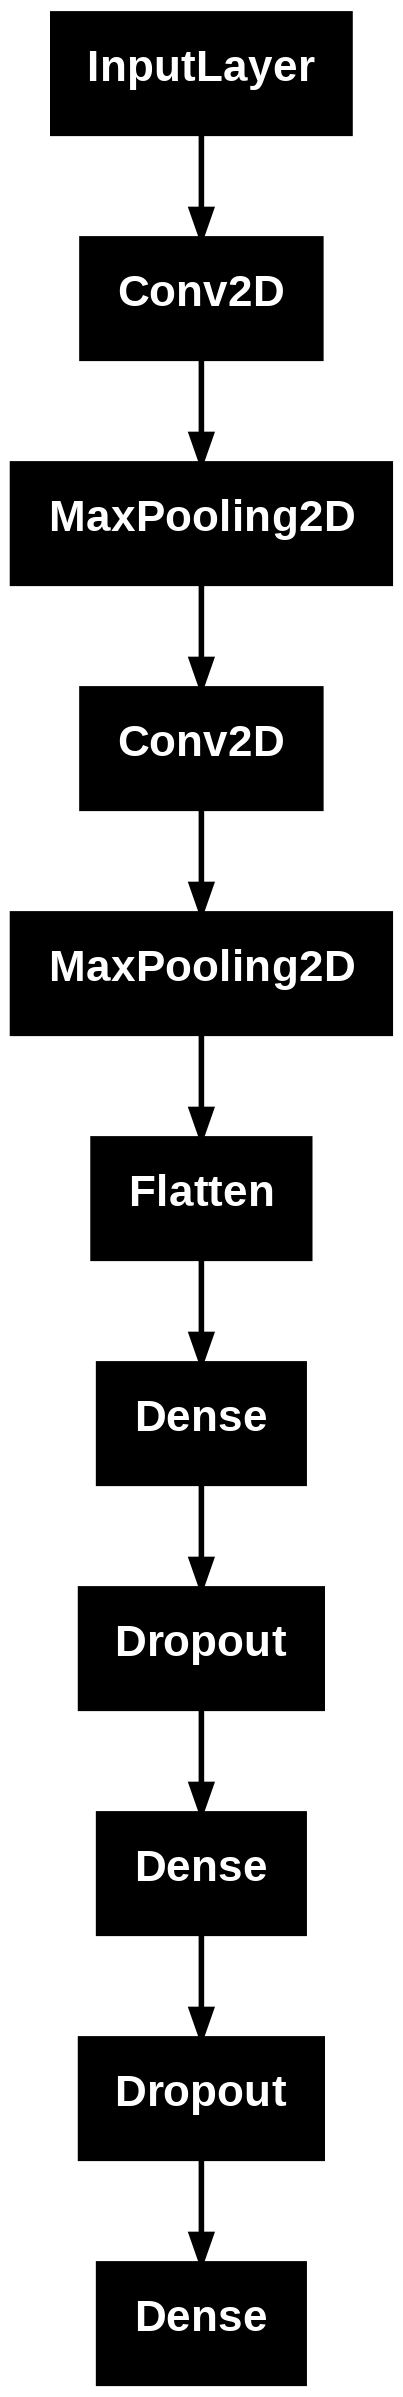

In [13]:
plot_model(model)

### Compilo el modelo

In [14]:
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

### Entrenamiento de la red

In [15]:
model.fit(images_train,labels_train,validation_data=[images_test,labels_test],
         epochs=10,batch_size=5000,verbose=1)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 158s 13s/step - accuracy: 0.1524 - loss: 2.2993 - val_accuracy: 0.3141 - val_loss: 2.2819
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 203s 13s/step - accuracy: 0.3533 - loss: 2.1683 - val_accuracy: 0.4031 - val_loss: 1.8764
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 198s 13s/step - accuracy: 0.4457 - loss: 1.5564 - val_accuracy: 0.5652 - val_loss: 1.2081
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 201s 13s/step - accuracy: 0.5283 - loss: 1.1655 - val_accuracy: 0.6272 - val_loss: 0.9891
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 152s 13s/step - accuracy: 0.5952 - loss: 1.0133 - val_accuracy: 0.6743 - val_loss: 0.8872
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 202s 13s/step - accuracy: 0.6521 - loss: 0.9061 - val_accuracy: 0.7025 - val_loss: 0.8148
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 148s 12s/step - accuracy: 0.6894 - loss: 0.8319 - val_accuracy: 0.7170 - val_loss: 0.7718
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 153s 13s/step - accuracy: 0.7084 - loss: 0.7811 - val_accuracy: 0.

## Predicciones con la red neuronal

In [16]:
pred = model.predict(images_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


In [18]:
labels_test_predicted=np.argmax(pred,1)

In [19]:
y_true=np.argmax(labels_test,axis=1)

In [40]:
# Predicciones validas
rango = int((y_true==labels_test_predicted).sum())

In [23]:
a=y_true==labels_test_predicted # Le asigno una variable a la cantidad de predicciones validas

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline

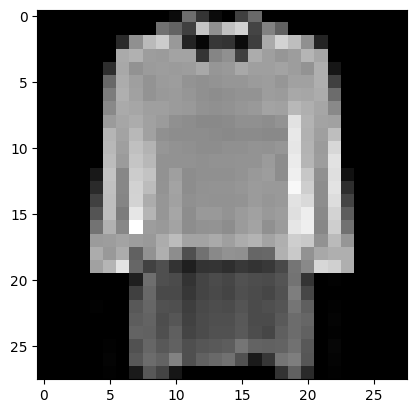

Clase real: 6
Clase que predice:  2


In [47]:
ind=np.random.randint(1, rango)
sample_image = images_test[ind,:,:,:]
# sample_image = np.array(sample_image, dtype='float')
pixels = sample_image.reshape((28, 28))
plt.imshow(pixels, cmap='gray')
plt.show()
print('Clase real:',np.argmax(labels_test[ind]))
print('Clase que predice: ',labels_test_predicted[ind])